### COMMON INSTRUCTIONS
Make sure to follow these instructions in order to ensure your submission is gradeable. If the automatic grading fails (check via Validate), no points are assigned!
1. Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel $\rightarrow$ Restart) and then **run all cells** (in the menubar, select Cell $\rightarrow$ Run All).
2. Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE".
3. If you work in a group, please always work and submit in a shared server under the name of your group.
   If you work alone, then always work and submit on the server called "My Server".
4. Using Large Language Models and other AI tools is discouraged. Do not paste external code, as it can be tracked!
5. Do not upload notebooks. Always work in notebooks on the server.
6. Do not copy cells inside a notebook. Add a new cell and copy code from another cell if needed.

In [1]:
!tar czf myfiles.tar.gz ./*

tar: ./myfiles.tar.gz: file changed as we read it


---

# eXplainable AI, Assignment 3 
# Ulm University - Institute of Artificial Intelligence
# Summer Term 2026 - Due: Tue, May 6, 2026, 2pm - Moodle

# Data preparation

Please run the code below to load and prepare the dataset.

In [2]:
from IPython.core.interactiveshell import InteractiveShell

InteractiveShell.ast_node_interactivity = "all"

!pip3 install matplotlib
import matplotlib.pyplot as plt

!pip3 install numpy
import numpy as np

!pip3 install pandas
import pandas as pd

!pip3 install scikit-learn
from sklearn.model_selection import train_test_split

dataset = pd.read_csv("housing_prices.csv", index_col=0).sample(n=200, random_state=1)

FEATURE_COLUMNS = [
    "sqft_living",
    "sqft_lot",
    "bedrooms",
    "bathrooms",
    "floors",
    "yr_built",
    "grade",
]
TARGET_COLUMN = ["price"]

X_train, X_test, y_train, y_test = train_test_split(
    dataset[FEATURE_COLUMNS], dataset[TARGET_COLUMN], train_size=0.66, random_state=1337
)
from sklearn.ensemble import RandomForestRegressor

regressor = RandomForestRegressor(
    max_depth=4,
    n_estimators=50,
    random_state=1337,
)
regressor.fit(X_train, y_train)

from sklearn.metrics import r2_score

train_r2 = r2_score(y_train, regressor.predict(X_train))
test_r2 = r2_score(y_test, regressor.predict(X_test))

print(train_r2, test_r2)

  Using cached matplotlib-3.10.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.3-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (362 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (5.0 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-manylinux2014_x86_64.manylinux_2_17_x86_64.w

/opt/conda/lib/python3.13/site-packages/sklearn/base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


# 1. Partial Dependence Plots (6pts total)

We will now have a closer look at partial dependence plots.
For plotting of PD values you may use the following `plot_pd_values` method:

In [3]:
def plot_pd_values(feature_values: list[float], pd_values: list[float], feature_name: str = None):
    """Plot PD values against their feature values (should be sorted ascending)."""
    fig = plt.figure()
    ax = plt.axes()
    ax.plot(feature_values, pd_values)
    if feature_name is not None: ax.set_xlabel(feature_name)
    plt.show()

## 1.1. Partial Dependence Function (3pts)
Implement the following method to calculate the values for a partial dependance plot as presented in the lecture. This is also called the partial dependence function.

In [4]:
def calculate_pd_values(feature_to_calc, dataset=X_train, regressor=regressor) -> tuple[list[int], list[float]]:
    """Return a tuple (feature_values, pd_values)
    of lists with matching feature values (sorted ascending) and their PD values
    for the feature `feature_to_calc`.
    """
    # YOUR SOLUTION HERE
    feature_values=sorted(dataset[feature_to_calc].unique())
    pd_values=[]
    for value in feature_values:
        dataset_mod=dataset.copy()
        dataset_mod[feature_to_calc]=value
        predictions=regressor.predict(dataset_mod)
        pd_value=predictions.mean()
        pd_values.append(pd_value)
    return feature_values,pd_values
    

In [5]:
# (hidden tests)
print('Success!')

Success!


## 1.2. PD Plotting (0.5pts)
Calculate PD values of all features using your implemented function from above and plot them (remember that you may use the provided plotting function from above).
Which of the features would you describe as most influential and why?

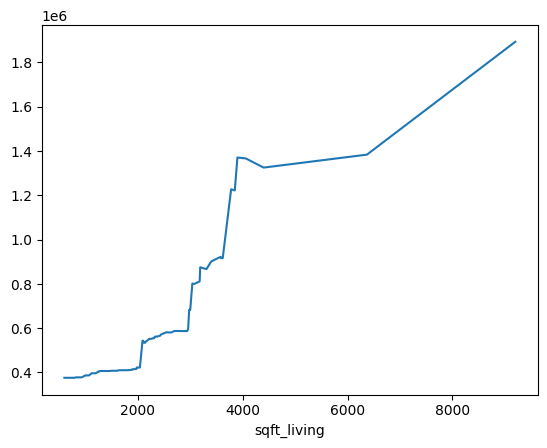

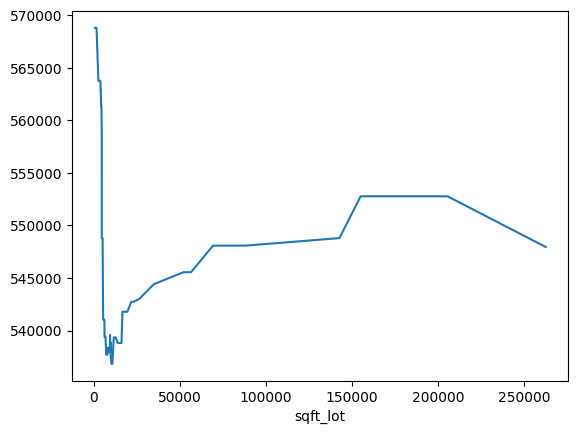

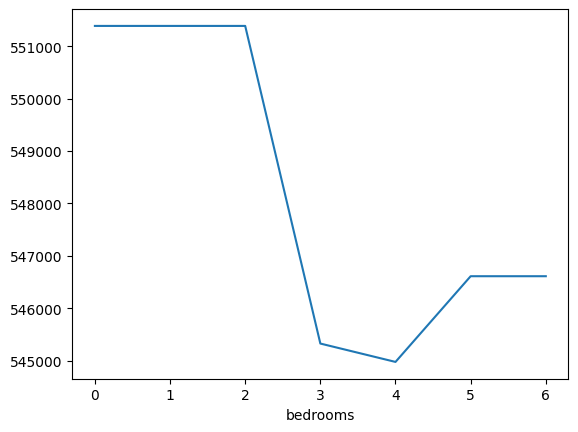

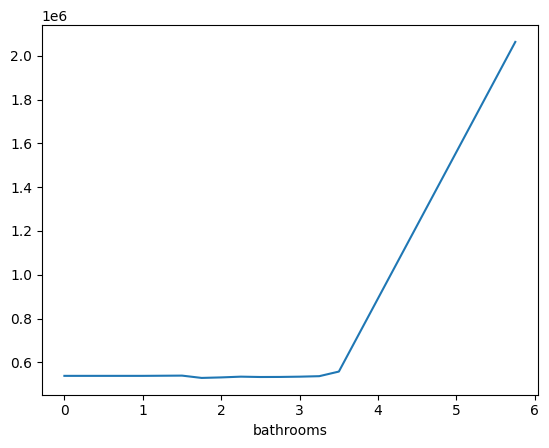

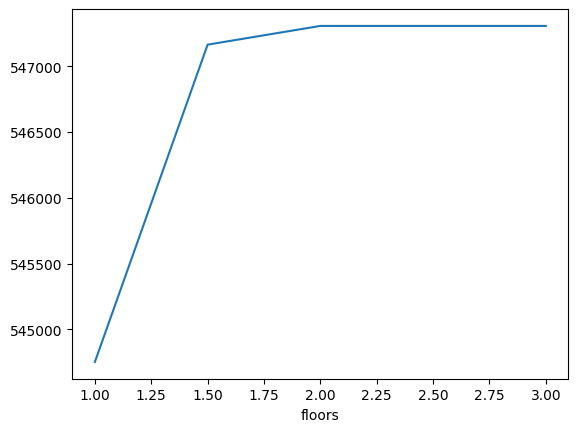

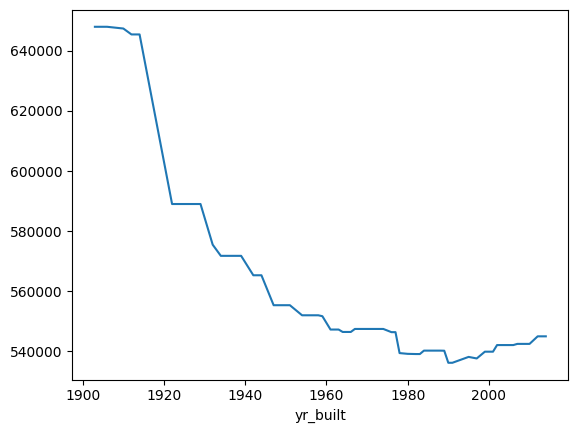

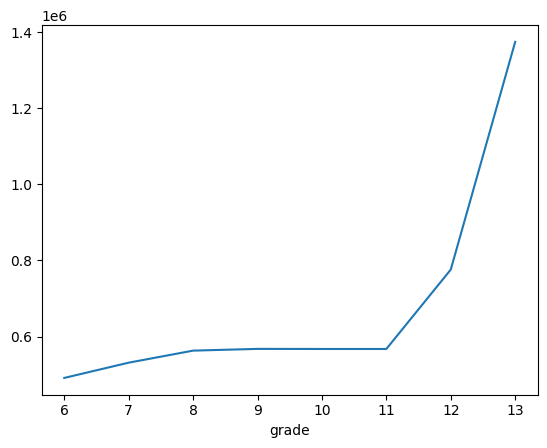

In [6]:
# YOUR SOLUTION HERE
for col in X_train.columns:
    feature,pd_values=calculate_pd_values(feature_to_calc=col,
                                          dataset=X_train,
                                          regressor= regressor)
    plot_pd_values(feature_values=feature, 
                       pd_values=pd_values, 
                       feature_name=col)

YOUR ANSWER HERE
The most influential features are those whose PDP curves change the most across their values, because a larger change in PD values means that changing that feature has a stronger effect on the model’s predicted house price.

## 1.3 PD Feature Importance (2.5pts)
We will now take a look at how one could translate PD plots practically into a single feature importance value per feature.
Going by the practical intuition from the lecture, implement a function that calculates the PD values of a feature $i$ (e.g., using your method from above), and estimates a global feature importance value of $i$ as the (corrected) **variance of its PD values**.

Now calculate feature importance values for all features using your implemented function and print them out, both for the train as well as the test set. Compare the outcome on train and test splits: Can you spot differences?

In [7]:
def global_pd_feature_importance(df=X_train, regressor=regressor) -> tuple[list[float], list[str]]:
    """Calculate for each feature in the dataset the variance of its PD values as feature importance.
    The result is returned as two lists:
    - The feature importances, and
    - the respective feature names (should be sorted by name ascending).
    """
    feature_importances, feature_names = [], []
    # YOUR SOLUTION HERE
    for feature_name in sorted(df.columns):
        feature_values,pd_values = calculate_pd_values(feature_to_calc=feature_name,
                                                       dataset=df,
                                                       regressor=regressor)
        importance=np.var(pd_values)
        feature_importances.append(importance)
        feature_names.append(feature_name)
    return feature_importances, feature_names


for feature_importance, column in zip(*global_pd_feature_importance(X_train)):
    print(f"PDP Feature Importance on X_train for\t {column:<11}  is  {feature_importance}")

for feature_importance, column in zip(*global_pd_feature_importance(X_test)):
    print(f"PDP Feature Importance on X_test for\t {column:<11}  is  {feature_importance}")

PDP Feature Importance on X_train for	 bathrooms    is  178029182010.49146
PDP Feature Importance on X_train for	 bedrooms     is  7095191.422246754
PDP Feature Importance on X_train for	 floors       is  1182928.82014827
PDP Feature Importance on X_train for	 grade        is  74985358444.1011
PDP Feature Importance on X_train for	 sqft_living  is  70097367493.65446
PDP Feature Importance on X_train for	 sqft_lot     is  113822498.88151391
PDP Feature Importance on X_train for	 yr_built     is  899520847.4243293
PDP Feature Importance on X_test for	 bathrooms    is  106965860.67138961
PDP Feature Importance on X_test for	 bedrooms     is  3792623.791151642
PDP Feature Importance on X_test for	 floors       is  2364409.5987603115
PDP Feature Importance on X_test for	 grade        is  803708677.7818108
PDP Feature Importance on X_test for	 sqft_living  is  53850807358.942276
PDP Feature Importance on X_test for	 sqft_lot     is  109167777.17589922
PDP Feature Importance on X_test for	 yr

<Figure size 640x480 with 0 Axes>

<BarContainer object of 7 artists>

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'bathrooms'),
  Text(1, 0, 'bedrooms'),
  Text(2, 0, 'floors'),
  Text(3, 0, 'grade'),
  Text(4, 0, 'sqft_living'),
  Text(5, 0, 'sqft_lot'),
  Text(6, 0, 'yr_built')])

Text(0, 0.5, 'Variance of PD values')

Text(0.5, 1.0, 'Global PDP Feature Importance - Train')

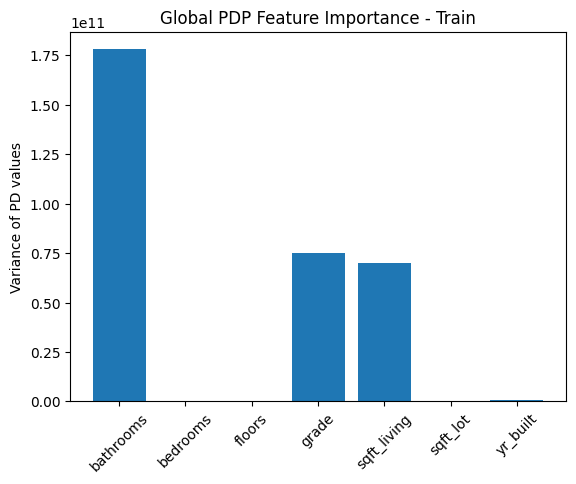

<Figure size 640x480 with 0 Axes>

<BarContainer object of 7 artists>

([0, 1, 2, 3, 4, 5, 6],
 [Text(0, 0, 'bathrooms'),
  Text(1, 0, 'bedrooms'),
  Text(2, 0, 'floors'),
  Text(3, 0, 'grade'),
  Text(4, 0, 'sqft_living'),
  Text(5, 0, 'sqft_lot'),
  Text(6, 0, 'yr_built')])

Text(0, 0.5, 'Variance of PD values')

Text(0.5, 1.0, 'Global PDP Feature Importance - Test')

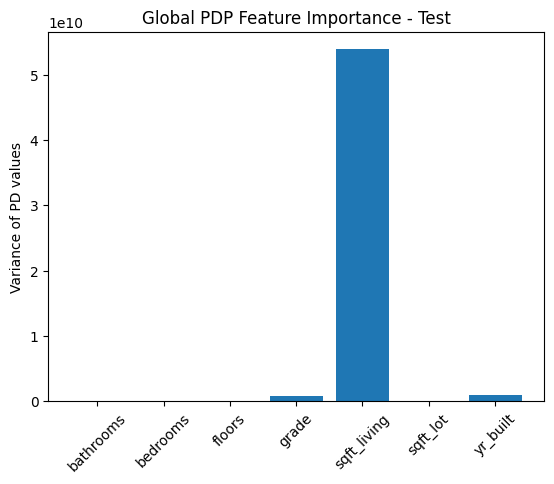

In [8]:
train_importances, train_features = global_pd_feature_importance(X_train)
test_importances, test_features = global_pd_feature_importance(X_test)

plt.figure()
plt.bar(train_features, train_importances);
plt.xticks(rotation=45);
plt.ylabel("Variance of PD values");
plt.title("Global PDP Feature Importance - Train");
plt.show()

plt.figure()
plt.bar(test_features, test_importances);
plt.xticks(rotation=45);
plt.ylabel("Variance of PD values");
plt.title("Global PDP Feature Importance - Test");
plt.show()

In [9]:
# (hidden tests)
print('Success!')

Success!


# 2. ICE (3pts total)

Now let's head back to go more local again.

## 2.1 ICE Implementation (2pts)
Similar to the PDP above, calculate and plot ICE explanations for the feature `yr_built` of the train dataset.

<Figure size 640x480 with 0 Axes>

Text(0.5, 0, 'yr_built')

Text(0, 0.5, 'Predicted price')

Text(0.5, 1.0, 'ICE plot for yr_built on X_train')

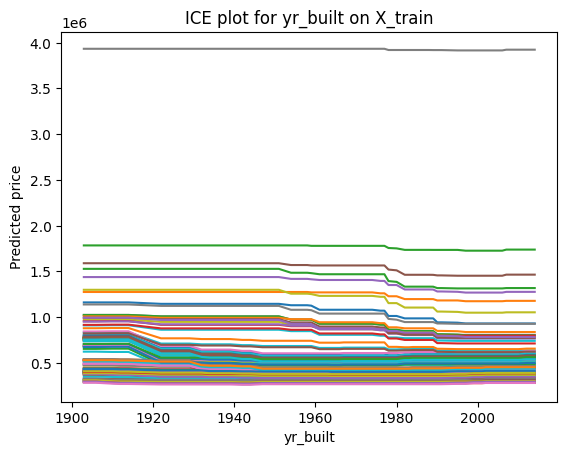

In [10]:
# YOUR SOLUTION HERE
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"
def calculate_ice_values(feature_to_calc,
                         dataset=X_train,
                         regressor=regressor):
    feature_values=sorted(dataset[feature_to_calc].unique())
    ice_values=[]
    for value in feature_values:
        dataset_mod=dataset.copy()
        dataset_mod[feature_to_calc]=value
        predictions=regressor.predict(dataset_mod)
        ice_values.append(predictions)
    ice_values=np.array(ice_values).T
    return feature_values,ice_values

feature_values,ice_values=calculate_ice_values(feature_to_calc="yr_built",
                                               dataset=X_train,
                                               regressor=regressor)
plt.figure()
for i in range(ice_values.shape[0]):
    plt.plot(feature_values,ice_values[i])
plt.xlabel("yr_built")
plt.ylabel("Predicted price")
plt.title("ICE plot for yr_built on X_train")
plt.show()

## 2.2 ICE benefits (1pts)
How does this differ from the PDP above? What the added benefit?

Unlike the PDP, which shows only the average effect of yr_built on the model prediction, the ICE plot shows the effect for each individual house. The added benefit is that ICE reveals whether all observations follow the same patter or whether some houses behave differently, which the PDP can hide because it averages everything.

# 3. Feature Interaction (3pts)

Implement the two-way feature interaction for some features according to the definition in the lecture. You can re-use your methods from the PDP exercise above, or you can now use the sklearn implementation (in case you did not implement multi-column calculation). Print out interactions between each pair of features from the dataset.

In [11]:
from sklearn.inspection import partial_dependence  # in case you want to use the sklearn implementation

def H(j: str, k: str, df=X_train) -> float:
    h = None
    # YOUR SOLUTION HERE
    j_values=sorted(df[j].unique())
    k_values=sorted(df[k].unique())

    _,pd_j=calculate_pd_values(j,dataset=df,
                               regressor=regressor)
    _,pd_k=calculate_pd_values(k,dataset=df,
                               regressor=regressor)
    pd_j=np.array(pd_j)
    pd_k=np.array(pd_k)

    pd_jk=[]
    for j_value in j_values:
        row=[]
        for k_value in k_values:
            df_mod=df.copy()
            df_mod[j]=j_value
            df_mod[k]=k_value
            row.append(regressor.predict(df_mod).mean())
        pd_jk.append(row)
    pd_jk=np.array(pd_jk)

    
    pd_jk = np.array(pd_jk)

    pd_j = pd_j - pd_j.mean()
    pd_k = pd_k - pd_k.mean()
    pd_jk = pd_jk - pd_jk.mean()

    interaction = pd_jk - pd_j[:, None] - pd_k[None, :]

    numerator = np.sum(interaction ** 2)
    denominator = np.sum(pd_jk ** 2)

    if denominator == 0:
        h = 0.0
    else:
        h = np.sqrt(numerator / denominator)
   
    return h


for j_col in X_train.columns:
    for k_col in X_train.columns:
        if j_col == k_col:  # we don't need interaction with itself
            continue
        print(f"Interaction between {j_col:<11} and {k_col:<11} is {H(j_col, k_col, df=X_train)}")

Interaction between sqft_living and sqft_lot    is 0.03310696775240831
Interaction between sqft_living and bedrooms    is 0.031371520319516476
Interaction between sqft_living and bathrooms   is 0.03833893752433729
Interaction between sqft_living and floors      is 0.0066340429942268585
Interaction between sqft_living and yr_built    is 0.10328727230243648
Interaction between sqft_living and grade       is 0.03962088285655124
Interaction between sqft_lot    and sqft_living is 0.0331069677524083
Interaction between sqft_lot    and bedrooms    is 0.040383728674348605
Interaction between sqft_lot    and bathrooms   is 0.0030784151512009885
Interaction between sqft_lot    and floors      is 0.0013620295764365212
Interaction between sqft_lot    and yr_built    is 0.043252452373538315
Interaction between sqft_lot    and grade       is 0.005142344655543602
Interaction between bedrooms    and sqft_living is 0.03137152031951648
Interaction between bedrooms    and sqft_lot    is 0.040383728674348

In [12]:
# (hidden tests)
print('Success!')

Success!


# 4. (BONUS) Permutation Feature Importance (3pts)

Implement the permutation feature importance method from the lecture according to the algorithm by Fisher, Rudin, and Dominici (2018) as provided in the [book by Molnar](https://christophm.github.io/interpretable-ml-book/feature-importance.html#theory).

Then apply it to the training dataset. 
(What differences do you see compared to PDP?)

In [15]:
from sklearn.metrics import mean_squared_error

def permutation_feature_importance(X=X_train, y=y_train, regressor=regressor
                                  ) -> tuple[list[float], list[str]]:
    
    feature_names = sorted(list(X.columns))
    permutation_importances: list[float] = []

    # We first need to know the original error
    global_mse = mean_squared_error(y, regressor.predict(X))
    random_state=42
    rng = np.random.default_rng(random_state)
    # YOUR SOLUTION HERE
    for feature in feature_names:
        X_permuted = X.copy()
    
        # Shuffle only this feature
        X_permuted[feature] = rng.permutation(X_permuted[feature].values)
    
        # Error after destroying this feature
        permuted_mse = mean_squared_error(y, regressor.predict(X_permuted))
    
        # Importance = increase in error
        importance = permuted_mse - global_mse
    
        permutation_importances.append(importance)
    return permutation_importances, feature_names


for feature_importance, column in zip(*permutation_feature_importance(X=X_test, y=y_test)):
    print(f"Permutation Feature Importance on X_test for\t {column:<11}  is  {feature_importance}")

for feature_importance, column in zip(*permutation_feature_importance(X=X_train, y=y_train)):
    print(f"Permutation Feature Importance on X_train for\t {column:<11}  is  {feature_importance}")

Permutation Feature Importance on X_test for	 bathrooms    is  4795470271.96875
Permutation Feature Importance on X_test for	 bedrooms     is  230004659.50912476
Permutation Feature Importance on X_test for	 floors       is  -130170840.09597778
Permutation Feature Importance on X_test for	 grade        is  6245863997.910187
Permutation Feature Importance on X_test for	 sqft_living  is  71079898931.7514
Permutation Feature Importance on X_test for	 sqft_lot     is  852043295.3072052
Permutation Feature Importance on X_test for	 yr_built     is  12806142746.1017
Permutation Feature Importance on X_train for	 bathrooms    is  68212242996.83851
Permutation Feature Importance on X_train for	 bedrooms     is  840143468.0103302
Permutation Feature Importance on X_train for	 floors       is  137519010.75679016
Permutation Feature Importance on X_train for	 grade        is  32083725232.09414
Permutation Feature Importance on X_train for	 sqft_living  is  172567382420.50082
Permutation Feature I

In [ ]:
# (hidden tests)
print('Success!')

       feature         train          test
4  sqft_living  1.725674e+11  7.107990e+10
6     yr_built  8.595751e+09  1.280614e+10
3        grade  3.208373e+10  6.245864e+09
0    bathrooms  6.821224e+10  4.795470e+09
5     sqft_lot  2.520689e+09  8.520433e+08
1     bedrooms  8.401435e+08  2.300047e+08
2       floors  1.375190e+08 -1.301708e+08


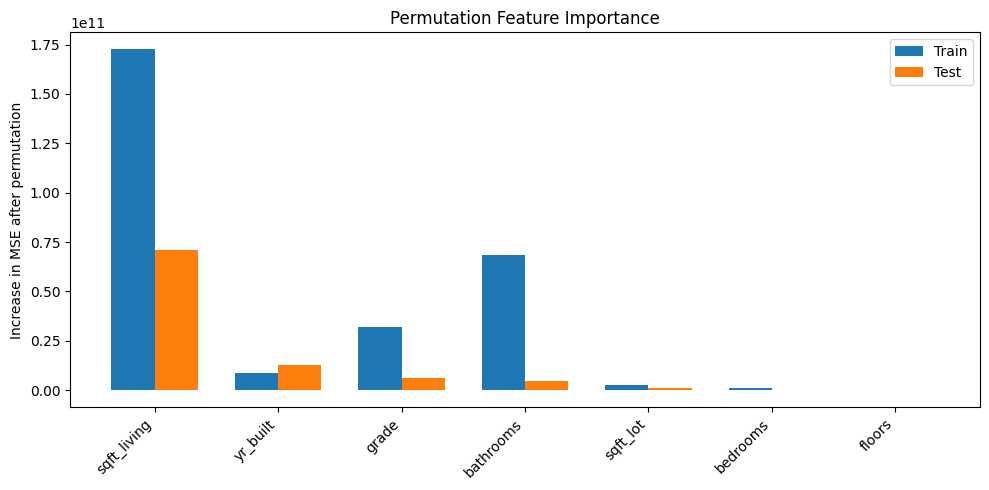

In [16]:

train_importance, train_features = permutation_feature_importance(X=X_train, y=y_train)
test_importance, test_features = permutation_feature_importance(X=X_test, y=y_test)

pfi_df = pd.DataFrame({
    "feature": train_features,
    "train": train_importance,
    "test": test_importance
}).sort_values("test", ascending=False)

print(pfi_df)

# Plot
x = np.arange(len(pfi_df))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, pfi_df["train"], width, label="Train")
plt.bar(x + width/2, pfi_df["test"], width, label="Test")

plt.xticks(x, pfi_df["feature"], rotation=45, ha="right")
plt.ylabel("Increase in MSE after permutation")
plt.title("Permutation Feature Importance")
plt.legend()
plt.tight_layout()
plt.show()